## CIFAR10 Hessian Plots (Author: Adam Rokah)

In [5]:
from google.colab import drive
import sys, os

# 1) Mount Drive
drive.mount('/content/drive')

# 2) Go to /content and start clean
%cd /content
!rm -rf mixture-of-experts-project

# 3) Clone the project and checkout your branch
!git clone https://github.com/moe-project-uu/mixture-of-experts-project.git
%cd mixture-of-experts-project
!git checkout arokah
!git branch   # should show * arokah

# 4) Install into this Python environment
!{sys.executable} -m pip install -U pip setuptools wheel
!{sys.executable} -m pip install -r requirements.txt
!{sys.executable} -m pip install -e .


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
Cloning into 'mixture-of-experts-project'...
remote: Enumerating objects: 1700, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 1700 (delta 145), reused 130 (delta 130), pack-reused 1528 (from 2)
Receiving objects: 100% (1700/1700), 344.08 MiB | 15.95 MiB/s, done.
Resolving deltas: 100% (669/669), done.
/content/mixture-of-experts-project
Branch 'arokah' set up to track remote branch 'arokah' from 'origin'.
Switched to a new branch 'arokah'
* arokah
  main
Obtaining file:///content/mixture-of-experts-project
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mixture-of-experts-project (pyproject.toml) ...

In [6]:
# 5) Quick sanity check
import moe
print("Imported moe from:", moe.__file__)

Imported moe from: /content/mixture-of-experts-project/src/moe/__init__.py


In [8]:
%cd /content/mixture-of-experts-project

/content/mixture-of-experts-project


In [9]:
models = {
    "Dense":     os.path.join(base, "Dense",     "E50"),
    "SoftMoE":   os.path.join(base, "SoftMoE",   "E50-X8"),
    "SparseMoE": os.path.join(base, "SparseMoE", "E50-X8-K2"),
}

for name, path in models.items():
    print(name, "=>", os.listdir(path))


Dense => ['summary.json', 'model.pt', 'metrics.pt']
SoftMoE => ['summary.json', 'model.pt', 'metrics.pt']
SparseMoE => ['summary.json', 'model.pt', 'metrics.pt']


In [28]:
!pwd

/content/mixture-of-experts-project


In [32]:
#Dense
!python scripts/cifar10_hessian.py \
    --ckpt_dir "/content/drive/MyDrive/moe_project/checkpoints/Dense/E50" \
    --data_dir "./data" \
    --num_train 1000 \
    --num_test 1000 \
    --curv_eps 0.5 \
    --curv_points 21



Loaded summary from /content/drive/MyDrive/moe_project/checkpoints/Dense/E50/summary.json
FF_layer=Dense | num_experts=4
[HESSIAN] Computing train-set stats (and curvature)...
[HESSIAN] Computing top eigenvalues...
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1291.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[HESSIAN] Done top eigenvalues.
[HESSIAN] Computing trace (Hutchinson)...
[HESSIAN] Done trace.
[HESSIAN] Computing spectral density (SLQ)...
[HESSIAN] Skipping spectral

In [33]:
# SoftMoE
!python scripts/cifar10_hessian.py \
    --ckpt_dir "/content/drive/MyDrive/moe_project/checkpoints/SoftMoE/E50-X8" \
    --data_dir "./data" \
    --num_train 1000 \
    --num_test 1000 \
    --curv_eps 0.5 \
    --curv_points 21

Loaded summary from /content/drive/MyDrive/moe_project/checkpoints/SoftMoE/E50-X8/summary.json
FF_layer=SoftMoE | num_experts=8
[HESSIAN] Computing train-set stats (and curvature)...
[HESSIAN] Computing top eigenvalues...
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1291.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[HESSIAN] Done top eigenvalues.
[HESSIAN] Computing trace (Hutchinson)...
[HESSIAN] Done trace.
[HESSIAN] Computing spectral density (SLQ)...
[HESSIAN] Skipping s

In [34]:
# SparseMoE
!python scripts/cifar10_hessian.py \
    --ckpt_dir "/content/drive/MyDrive/moe_project/checkpoints/SparseMoE/E50-X8-K2" \
    --data_dir "./data" \
    --num_train 1000 \
    --num_test 1000 \
    --curv_eps 0.5 \
    --curv_points 21

Loaded summary from /content/drive/MyDrive/moe_project/checkpoints/SparseMoE/E50-X8-K2/summary.json
FF_layer=SparseMoE | num_experts=8
[HESSIAN] Computing train-set stats (and curvature)...
[HESSIAN] Computing top eigenvalues...
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1291.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
[HESSIAN] Done top eigenvalues.
[HESSIAN] Computing trace (Hutchinson)...
[HESSIAN] Done trace.
[HESSIAN] Computing spectral density (SLQ)...
[HESSIAN] Ski

In [38]:
import torch

hessian_data = {
    "Dense": torch.load(
        "/content/drive/MyDrive/moe_project/checkpoints/Dense/E50/hessian.pt",
        weights_only=False,
    ),
    "SoftMoE": torch.load(
        "/content/drive/MyDrive/moe_project/checkpoints/SoftMoE/E50-X8/hessian.pt",
        weights_only=False,
    ),
    "SparseMoE": torch.load(
        "/content/drive/MyDrive/moe_project/checkpoints/SparseMoE/E50-X8-K2/hessian.pt",
        weights_only=False,
    ),
}


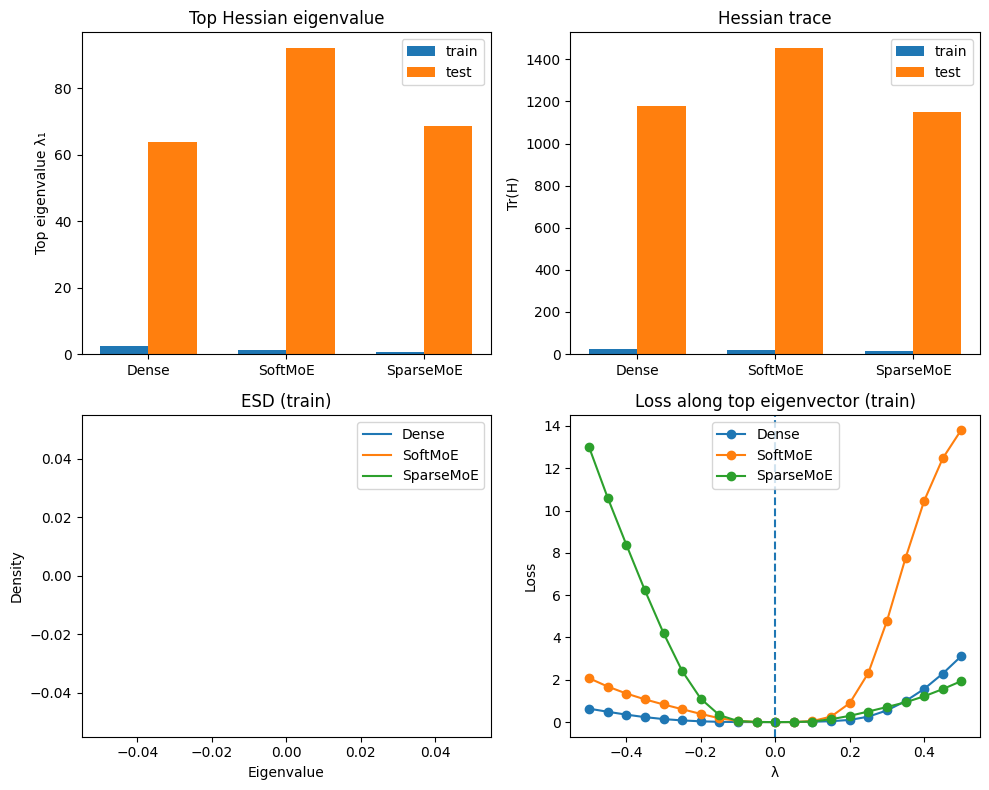

In [41]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(hessian_data.keys())
n_models = len(labels)

# Collect stats
lambda_train = [hessian_data[m]["hessian"]["train"]["lambda_max"] for m in labels]
lambda_test  = [hessian_data[m]["hessian"]["test"]["lambda_max"]  for m in labels]
trace_train  = [hessian_data[m]["hessian"]["train"]["trace"]      for m in labels]
trace_test   = [hessian_data[m]["hessian"]["test"]["trace"]       for m in labels]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax1, ax2, ax3, ax4 = axes.flat

x = np.arange(n_models)
width = 0.35

# -------- (1) Top eigenvalue: train vs test --------
ax1.bar(x - width/2, lambda_train, width, label="train")
ax1.bar(x + width/2, lambda_test,  width, label="test")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel("Top eigenvalue λ₁")
ax1.set_title("Top Hessian eigenvalue")
ax1.legend()

# -------- (2) Trace: train vs test --------
ax2.bar(x - width/2, trace_train, width, label="train")
ax2.bar(x + width/2, trace_test,  width, label="test")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Tr(H)")
ax2.set_title("Hessian trace")
ax2.legend()

# -------- (3) ESD (train) --------
for m in labels:
    es = hessian_data[m]["hessian"]["train"]["density_eigs"]
    ws = hessian_data[m]["hessian"]["train"]["density_weights"]
    ax3.plot(es, ws, label=m)

ax3.set_xlabel("Eigenvalue")
ax3.set_ylabel("Density")
ax3.set_title("ESD (train)")
ax3.legend()

# -------- (4) Curvature (loss vs λ along top eigenvector, train) --------
for m in labels:
    alphas = np.array(hessian_data[m]["hessian"]["train"]["curvature_alphas"])
    losses = np.array(hessian_data[m]["hessian"]["train"]["curvature_losses"])
    ax4.plot(alphas, losses, marker="o", label=m)

ax4.axvline(0.0, linestyle="--")
ax4.set_xlabel("λ")
ax4.set_ylabel("Loss")
ax4.set_title("Loss along top eigenvector (train)")
ax4.legend()

plt.tight_layout()
plt.show()
